# 08 - Shipping it: conformal prediction with MAPIE

> "Great prototype. What do we actually put in the repo?" — Hearthstone's engineering lead, sprint planning

The methods review went well. The desk trusts the intervals, legal has signed off on the
slice tables, and now the question is an engineering one. Behind it sits a sharper
statistical question: can a maintained library reproduce the guarantee we built by hand —
on the same data split, to the same decimal places — and which parts of the job does a
library *not* do for us? This notebook answers both, on real public data for the first
time in the series.

What you will learn:

- How MAPIE's `fit` / `conformalize` / `predict_interval` API maps line for line onto the
  fifteen-line recipe from notebook 02, and how to verify the match on a known case before
  trusting any library.
- How to run this series' toolbox — split conformal, CQR (notebook 05), CV+ (notebook 06) —
  on one real dataset and read the comparison table like a reviewer.
- What conformal classification looks like in six lines, and which variant to reach for
  when the dataset is tiny.
- A translation table from this series' vocabulary to MAPIE's, and the pre-launch
  checklist we would hand to any team shipping conformal prediction.

Where we are in the series: this is notebook 08 of 8. Notebook 07 stress-tested the one
real assumption (exchangeability); this notebook takes everything we built and ships it.

## 1. From notebook code to a dependency

The core of split conformal prediction is fifteen lines of numpy, and we have implemented
it from scratch several times by now. So why take on a dependency at all?

Because the fifteen lines are the easy part. A production implementation also has to
handle the edge cases we met one at a time across this series: tied scores, calibration
sets too small for the requested alpha (where the only honest interval is infinite,
field guide §1), several confidence levels served from one calibration pass, and the exact
quantile convention that decides whether you are one order statistic conservative or one
order statistic invalid. It also has to implement the newer methods — CQR, CV+,
jackknife-after-bootstrap, APS — correctly, with someone else's unit tests standing behind
them, and expose it all through an API your teammates already know how to read. That is
what **MAPIE** is: an open-source, scikit-learn-style library for conformal prediction,
the closest thing the field has to a standard tool. (An alternative worth knowing by name
is `crepes`, which builds everything around explicit score objects; we will not use it
here.)

What a library cannot do is the judgment work of notebooks 01–07. It cannot choose alpha
with your business owner, cannot check that your calibration data is exchangeable with
production, cannot read a slice-coverage table for you, and cannot decide what your
product does when a prediction set comes back embarrassingly large. You bring the
statistics; the library brings the plumbing.

The plan: reproduce our own numbers with MAPIE on real data (section 3), run the whole
toolbox on one dataset (section 4), do classification in six lines (section 5), then
close the series with the translation table, the pre-launch checklist, and a reading
list.

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import mapie
from mapie.classification import CrossConformalClassifier, SplitConformalClassifier
from mapie.metrics.classification import classification_coverage_score
from mapie.metrics.regression import (
    regression_coverage_score,
    regression_mean_width_score,
)
from mapie.regression import (
    ConformalizedQuantileRegressor,
    CrossConformalRegressor,
    SplitConformalRegressor,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
RANDOM_SEED = 20260707

BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED",
)

alpha = 0.10  # the series-wide error budget: a 90% coverage target

# MAPIE's API changed sharply at 1.0 -- everything below is written against this version.
print(f"mapie version: {mapie.__version__}")

mapie version: 1.4.1


## 2. California, for real this time

Seven notebooks of simulated Riverton listings earned us one luxury: we always knew the
true data-generating process. Real data revokes that luxury, which is exactly why it makes
a good graduation exercise. The California housing dataset contains 20,640 census districts
from the 1990 census, each described by 8 features (median income, house age, average
rooms and bedrooms, population, occupancy, latitude, longitude). The target is the
district's median house value in units of $100,000, so `y = 2.0` means $200,000. One
quirk to know up front: the census capped the recorded value at 5.0, so every district
worth more than $500,000 sits exactly at 5.0. The first call to
`fetch_california_housing` downloads the data; after that it is cached locally.

We cut the data three ways, and the order of the cuts matters (field guide §2): 12,000
districts to train on, 4,000 as the calibration set (notebook 02) — held-out labeled data
whose only job is to measure how wrong the model tends to be — and 4,640 for testing the
claims we make.

In [2]:
housing = fetch_california_housing()
X, y = housing.data, housing.target  # y = median house value, units of $100k

print(f"districts: {X.shape[0]}, features: {X.shape[1]}")
print(f"feature names: {housing.feature_names}")
print(f"target: median ${np.median(y) * 1e5:,.0f}, "
      f"min ${y.min() * 1e5:,.0f}, max ${y.max() * 1e5:,.0f}")
print(f"share of districts sitting at the 5.0 cap: {np.mean(y >= 5.0):.4f}")

# Split FIRST, fit later, calibrate once -- the calibration set must never touch training.
X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, train_size=12000, random_state=RANDOM_SEED
)
X_cal, X_test, y_cal, y_test = train_test_split(
    X_rest, y_rest, train_size=4000, random_state=RANDOM_SEED
)
print(f"train / calibration / test: {len(y_train)} / {len(y_cal)} / {len(y_test)}")

districts: 20640, features: 8
feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
target: median $179,700, min $14,999, max $500,001
share of districts sitting at the 5.0 cap: 0.0481
train / calibration / test: 12000 / 4000 / 4640


The median district is worth $179,700 and 4.8% of districts sit exactly at the $500,001
cap — not a rounding artifact but a hard ceiling in how the data was recorded. That
matters later: districts at the cap are a slice where the recorded "truth" is itself
censored, and no interval method knows that unless we do. The 4,000-point calibration set
is deliberately comfortable: field guide §4 says roughly a thousand points keeps a 90%
target within about 0.88–0.92, and we have four times that. The histogram below shows the
cap as a spike.

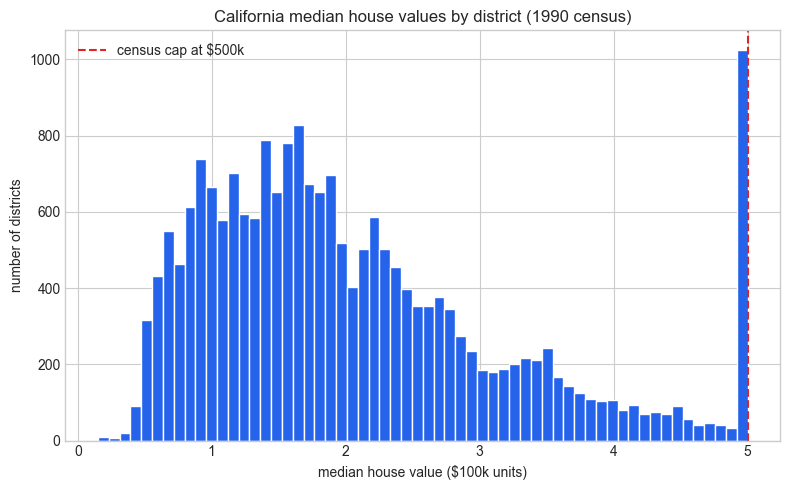

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y, bins=60, color=BLUE, edgecolor="white")
ax.axvline(5.0, color=RED, linestyle="--", linewidth=1.5, label="census cap at $500k")
ax.set_title("California median house values by district (1990 census)")
ax.set_xlabel("median house value ($100k units)")
ax.set_ylabel("number of districts")
ax.legend()
plt.tight_layout()
plt.show()

A right-skewed price distribution with a visible spike at the cap — about a thousand
districts piled up at 5.0. The skew should feel familiar: it is the same shape the
Hearthstone simulator produced, because housing prices really do behave this way, with
more spread among expensive homes than cheap ones. Keep that in mind for section 4.

The base model is the same one Hearthstone has used all series:
`GradientBoostingRegressor` with sklearn defaults, seeded for reproducibility. Nothing
about conformal prediction depends on this choice — that is the point of a wrapper — but
keeping the model fixed makes widths comparable across the notebooks.

In [4]:
model = GradientBoostingRegressor(random_state=RANDOM_SEED)
model.fit(X_train, y_train)

mae = mean_absolute_error(y_test, model.predict(X_test))
print(f"fitted on {len(y_train)} districts")
print(f"test MAE: {mae:.4f} ($100k units) = ${mae * 1e5:,.0f} typical error")

fitted on 12000 districts
test MAE: 0.3718 ($100k units) = $37,182 typical error


## 3. The moment of truth: MAPIE vs our fifteen lines

The model's typical error is $37,182 on a median price of $179,700 — a point prediction
you would not want to wire money against without an interval around it. So we build one,
twice: once with the recipe from notebook 02, once with MAPIE, on the identical split,
and we demand the numbers agree.

First, the recipe, verbatim. The nonconformity score — the weirdness meter that says
how badly the model disagrees with a candidate answer — is the absolute residual
`|y - prediction|`. The threshold is the corrected quantile: in words, sort the
calibration scores and take the one at rank ceiling-of-(n+1)(1−alpha), rather than the
plain (1−alpha) sample quantile — the small upward bump is what makes the finite-sample
guarantee exact instead of approximate. In symbols, $\hat{q}$ is the
$\lceil (n+1)(1-\alpha) \rceil / n$ empirical quantile of the $n$ calibration scores,
where $\alpha$ is the miscoverage budget (0.10 here). The prediction interval is the
point prediction plus or minus $\hat{q}$.

In [5]:
# The fifteen-line fix from notebook 02, verbatim: absolute residuals as scores.
scores = np.abs(y_cal - model.predict(X_cal))  # nonconformity scores, calibration set only
n_cal = len(scores)

q_level = math.ceil((n_cal + 1) * (1 - alpha)) / n_cal
assert q_level <= 1.0, (
    "Calibration set too small for this alpha - the honest interval is infinite "
    "(field guide §1)"
)
q_hat = np.quantile(scores, q_level, method="higher")  # the corrected quantile

pred_test = model.predict(X_test)
lower_ours = pred_test - q_hat
upper_ours = pred_test + q_hat

covered_ours = (y_test >= lower_ours) & (y_test <= upper_ours)
coverage_ours = covered_ours.mean()
width_ours = np.mean(upper_ours - lower_ours)

print(f"calibration points:         {n_cal}")
print(f"corrected quantile level:   {q_level:.5f}")
print(f"q_hat (half-width, $100k):  {q_hat:.6f}")
print(f"empirical coverage:         {coverage_ours:.4f}  (target {1 - alpha:.2f})")
print(f"mean interval width:        {width_ours:.6f}  (${width_ours * 1e5:,.0f} end to end)")

calibration points:         4000
corrected quantile level:   0.90025
q_hat (half-width, $100k):  0.827740
empirical coverage:         0.9069  (target 0.90)
mean interval width:        1.655480  ($165,548 end to end)


Empirical coverage — the fraction of test districts whose true value falls inside the
interval — lands at 0.9069. With 4,640 test points, anything in roughly 0.891–0.909 is
within Monte Carlo noise of the 0.90 target, so the guarantee is doing exactly what
notebook 03 said it would. The price of that guarantee is a half-width of $82,774 on
every single district: honest, but one-size-fits-all. Note what 0.9069 does *not* mean:
it is not the probability that any particular district's interval is right, and it is not
a promise about any slice of the market — both caveats come back in section 4.

Now the same construction through MAPIE. The API splits our recipe into three verbs:
`fit` trains the underlying estimator (we skip it via `prefit=True`, since `model` is
already fitted and must not be refit), `conformalize` computes calibration scores and the
corrected quantile — exactly our lines 1–7 — and `predict_interval` builds the intervals.
Two vocabulary bumps to absorb: MAPIE asks for `confidence_level` (which is 1 − alpha,
not alpha), and it calls the score a `conformity_score`. Libraries and some papers say
"conformity" where this series says nonconformity, with the sign flipped or not — it is
the same weirdness meter either way.

In [6]:
mapie_split = SplitConformalRegressor(
    model,
    confidence_level=1 - alpha,    # MAPIE speaks confidence (0.90), not error (0.10)
    conformity_score="absolute",   # |y - prediction|, the notebook-02 score
    prefit=True,                   # "this model is already fitted -- do not touch it"
)
mapie_split.conformalize(X_cal, y_cal)               # scores + corrected quantile
pred_mapie, intervals = mapie_split.predict_interval(X_test)

print(f"intervals shape: {intervals.shape}  (test points, lower/upper, confidence levels)")
lower_mapie, upper_mapie = intervals[:, 0, 0], intervals[:, 1, 0]

assert np.allclose(pred_mapie, pred_test), "same fitted model -> same point predictions"

coverage_mapie = regression_coverage_score(y_test, intervals)[0]
width_mapie = regression_mean_width_score(intervals)[0]
half_width_mapie = np.mean(upper_mapie - lower_mapie) / 2

print(f"\n{'':26s}{'ours (numpy)':>14s}{'MAPIE':>14s}")
print(f"{'empirical coverage':26s}{coverage_ours:>14.4f}{coverage_mapie:>14.4f}")
print(f"{'mean width ($100k)':26s}{width_ours:>14.6f}{width_mapie:>14.6f}")
print(f"{'half-width = q_hat':26s}{q_hat:>14.6f}{half_width_mapie:>14.6f}")

# Where does MAPIE's number come from? The SAME sorted calibration scores.
sorted_scores = np.sort(scores)
k = math.ceil((n_cal + 1) * (1 - alpha))  # the rank the theory asks for: 3601 of 4000
print(f"\ncalibration score at rank {k} (of {n_cal}): {sorted_scores[k - 1]:.6f}"
      f"   <- MAPIE's half-width")
print(f"calibration score at rank {k + 1} (of {n_cal}): {sorted_scores[k]:.6f}"
      f"   <- our q_hat")
print(f"difference, in actual dollars: ${abs(q_hat - half_width_mapie) * 1e5:.2f}")

intervals shape: (4640, 2, 1)  (test points, lower/upper, confidence levels)

                            ours (numpy)         MAPIE
empirical coverage                0.9069        0.9069
mean width ($100k)              1.655480      1.655465
half-width = q_hat              0.827740      0.827733

calibration score at rank 3601 (of 4000): 0.827733   <- MAPIE's half-width
calibration score at rank 3602 (of 4000): 0.827740   <- our q_hat
difference, in actual dollars: $0.74


This is the payoff of the whole series, so read the printout slowly. Coverage is
identical to every decimal we print: 0.9069 for both, because on this test set the two
methods build intervals that differ by less than a dollar. Mean widths agree to four
decimals: 1.655480 versus 1.655465 in $100k units. And the last three lines show *why*
they are not identical to fifteen decimals: both half-widths are order statistics of the
same 4,000 sorted calibration scores. Theory asks for the score at rank 3601
(the ceiling of 4001 × 0.90); MAPIE returns exactly that score, 0.827733, while numpy's
`method="higher"` at level 0.90025 rounds its index up over the 4,000 sample points and
lands one rank higher, at 0.827740. Both choices sit at or above the rank the guarantee
needs, so both are valid; the gap between them is $0.74 on a median home price of
$179,700.

There was never any magic. MAPIE is our fifteen lines plus guardrails — we just audited a
maintained library down to the individual order statistic it picks, which is precisely
the verification step (field guide §1) we would demand before adding any dependency to
the repo. From here on we can use MAPIE's numbers and know exactly what stands behind
them.

One trap before moving on, and we will commit it live rather than describe it: the
`confidence_level` argument. A colleague who has alpha = 0.10 in their head — every paper
and every notebook in this series parameterizes by alpha — will sooner or later type it
straight into MAPIE.

In [7]:
# WRONG on purpose: passing alpha where MAPIE expects a confidence level.
wrong = SplitConformalRegressor(
    model, confidence_level=alpha, conformity_score="absolute", prefit=True
)
wrong.conformalize(X_cal, y_cal)
_, wrong_intervals = wrong.predict_interval(X_test)

wrong_coverage = regression_coverage_score(y_test, wrong_intervals)[0]
wrong_width = regression_mean_width_score(wrong_intervals)[0]
print(f"confidence_level={alpha}: coverage {wrong_coverage:.4f}, "
      f"mean width {wrong_width:.4f} (${wrong_width * 1e5:,.0f})")

# The fix: say what you mean. confidence_level = 1 - alpha.
print(f"confidence_level={1 - alpha}: coverage {coverage_mapie:.4f}, "
      f"mean width {width_mapie:.4f} (${width_mapie * 1e5:,.0f})")

confidence_level=0.1: coverage 0.1045, mean width 0.0966 ($9,658)
confidence_level=0.9: coverage 0.9069, mean width 1.6555 ($165,547)


No exception, no warning — `confidence_level=0.1` is a perfectly legal request for
intervals that cover 10% of the time, and MAPIE delivered exactly that: coverage 0.1045,
widths of $9,658 on assets worth hundreds of thousands. In a dashboard those skinny
intervals would look wonderfully precise right up until the desk noticed nine of every
ten homes closing outside them. The guard is procedural, not clever: name the argument
explicitly in code review, and keep a known-case coverage assertion in CI so a swapped
parameterization fails the build instead of the business.

## 4. The library's toolbox on one dataset

The point of a library is that the fancier methods from this series cost one line each
instead of one notebook each. We add the two that earned their place:

- **CQR (conformalized quantile regression)**, from notebook 05: fit quantile regressors
  for the 5th and 95th percentiles, then let the calibration set stretch or shrink that
  band until the 90% guarantee holds. Adaptive width — wide where the data is noisy,
  narrow where it is quiet. With `prefit=False` MAPIE fits three quantile models (lower,
  upper, median) from the estimator we hand it. That happens to be CQR's default — the
  opposite of the Split classes' — but we pass it explicitly so the code says what it does.
- **CV+**, from notebook 06: no held-out calibration set at all. Split the data into 10
  folds, fit 10 models, score each point with the model that never saw it. We hand it the
  pooled 16,000 train-plus-calibration districts, since not needing a separate
  calibration set is its entire pitch.

Same estimator family throughout (`GradientBoostingRegressor`, stated choice from the
outline of this series), so the table compares methods, not models.

In [8]:
# CQR: MAPIE clones this estimator into three quantile models (0.05, 0.50, 0.95).
qr_estimator = GradientBoostingRegressor(
    loss="quantile", alpha=0.5, random_state=RANDOM_SEED
)
cqr = ConformalizedQuantileRegressor(
    qr_estimator,
    confidence_level=1 - alpha,
    prefit=False,  # CQR's default is the OPPOSITE of the Split classes' -- say it out loud
)
cqr.fit(X_train, y_train)
cqr.conformalize(X_cal, y_cal)
pred_cqr, intervals_cqr = cqr.predict_interval(X_test)
lower_cqr, upper_cqr = intervals_cqr[:, 0, 0], intervals_cqr[:, 1, 0]

# CV+: gets train AND calibration data -- 10 fits, no data spent on calibration.
# An integer cv becomes a SHUFFLED KFold inside MAPIE; without random_state the
# folds (and your numbers) quietly change on every run.
cvplus = CrossConformalRegressor(
    GradientBoostingRegressor(random_state=RANDOM_SEED),
    confidence_level=1 - alpha, method="plus", cv=10, random_state=RANDOM_SEED,
)
X_pool = np.vstack([X_train, X_cal])
y_pool = np.concatenate([y_train, y_cal])
cvplus.fit_conformalize(X_pool, y_pool)
pred_cv, intervals_cv = cvplus.predict_interval(X_test)

toolbox = pd.DataFrame({
    "method": ["our fifteen lines (numpy)", "SplitConformalRegressor (absolute)",
               "ConformalizedQuantileRegressor", "CrossConformalRegressor (CV+)"],
    "series notebook": ["02", "02", "05", "06"],
    "coverage": [coverage_ours, coverage_mapie,
                 regression_coverage_score(y_test, intervals_cqr)[0],
                 regression_coverage_score(y_test, intervals_cv)[0]],
    "mean width ($100k)": [width_ours, width_mapie,
                           regression_mean_width_score(intervals_cqr)[0],
                           regression_mean_width_score(intervals_cv)[0]],
    "model fits": [1, 1, 3, 10],
}).set_index("method")
toolbox.round(3)

INFO:root:The predictions are ill-sorted.


INFO:root:The predictions are ill-sorted.


,series notebook,coverage,mean width ($100k),model fits
method,,,,
our fifteen lines (numpy),02,0.907,1.655,1
SplitConformalRegressor (absolute),02,0.907,1.655,1
ConformalizedQuantileRegressor,05,0.906,1.868,3
CrossConformalRegressor (CV+),06,0.904,1.631,10


Read the table with field guide §12 in mind: coverage, width, and (next cell) adaptivity,
never coverage alone. All four rows land within noise of 0.90 — 0.907, 0.907, 0.906,
0.904 — as the theory says they must; coverage cannot separate these methods, and anyone
who declares a winner on coverage is doing statistics theatre. Width does separate them.
CV+ is slightly the narrowest at 1.631 because each of its 10 models trains on 14,400
districts and no data is spent on calibration. CQR is the *widest* on average at 1.868,
and one caution: do not read that as CQR losing. Its average is wide because it spends
width where the noise lives; whether that spending is smart is what the slice table below
will show.

One printout above deserves a careful reading: MAPIE logged `The predictions are
ill-sorted` twice while running CQR. That is the library detecting **quantile crossing** —
the separately-fitted 5th and 95th percentile models occasionally cross each other on
hard inputs, which would make a "lower" bound sit above the "upper" — and repairing it by
re-sorting. Our homegrown CQR in notebook 05 would have silently produced a handful of
inside-out intervals. This is what "someone else's unit tests" buys.

So: does CQR's extra average width buy anything? Marginal coverage is an average over
everything, and field guide §3 warns it can hide slices. The natural slice for housing is
wealth — the California analogue of notebook 05's home-size bins — so we cut the test set
into quartiles of district median income and check conditional coverage, the per-slice
batting average that the theory deliberately does not guarantee.

In [9]:
medinc_test = X_test[:, 0]  # feature 0 is district median income
quartile = pd.qcut(medinc_test, 4,
                   labels=["Q1 (poorest)", "Q2", "Q3", "Q4 (richest)"])

rows = []
for method_name, lo, hi in [("constant width", lower_mapie, upper_mapie),
                            ("CQR", lower_cqr, upper_cqr)]:
    covered = (y_test >= lo) & (y_test <= hi)
    width = hi - lo
    for q in quartile.categories:
        mask = quartile == q
        rows.append({"income quartile": q, "method": method_name,
                     "coverage": covered[mask].mean(),
                     "mean width": width[mask].mean(),
                     "districts": int(mask.sum())})

slice_table = (pd.DataFrame(rows)
               .pivot(index="income quartile", columns="method",
                      values=["coverage", "mean width"]))
slice_table.round(3)

coverage                mean width               
method               CQR constant width        CQR constant width
income quartile                                                  
Q1 (poorest)       0.901          0.939      1.531          1.655
Q2                 0.892          0.920      1.724          1.655
Q3                 0.924          0.890      1.988          1.655
Q4 (richest)       0.907          0.879      2.229          1.655

The constant-width column is the quiet failure we have been hunting all series: overall
coverage said 0.907, but the slices say 0.939 for the poorest quartile sliding down to
0.879 for the richest. Same intervals, same guarantee, and the expensive districts — the
ones where a mispriced offer costs the most — get covered least, because one
$82,774 half-width is generous where homes are cheap and tight where they are pricey.
CQR runs 0.901, 0.892, 0.924, 0.907 across the same quartiles: no slice drifts far from
target, and its width column shows how it pays for that — $153k intervals in Q1 widening
to $223k in Q4. Two caveats so we do not over-read: with 1,160 districts per slice, noise
on each coverage number is roughly ±0.018, so 0.879 is a real shortfall but 0.924 versus
0.907 is not a meaningful difference; and nothing here says CQR *guarantees* per-slice
coverage — it just usually earns it (that would take group-balanced calibration,
notebook 04's trick).

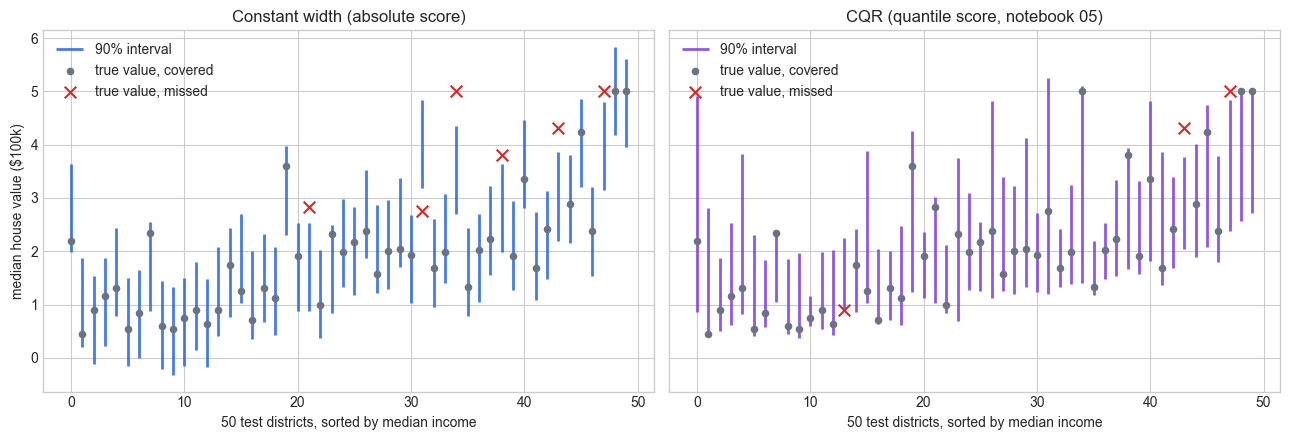

In [10]:
rng = np.random.default_rng(RANDOM_SEED)
sample = rng.choice(len(y_test), size=50, replace=False)
order = sample[np.argsort(medinc_test[sample])]  # sort the 50 districts by income
xs = np.arange(len(order))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
panels = [("Constant width (absolute score)", lower_mapie, upper_mapie, BLUE),
          ("CQR (quantile score, notebook 05)", lower_cqr, upper_cqr, PURPLE)]
for ax, (title, lo_all, hi_all, color) in zip(axes, panels):
    lo, hi, truth = lo_all[order], hi_all[order], y_test[order]
    missed = (truth < lo) | (truth > hi)
    ax.vlines(xs, lo, hi, color=color, linewidth=2, alpha=0.85, label="90% interval")
    ax.scatter(xs[~missed], truth[~missed], color=GRAY, s=20, zorder=3,
               label="true value, covered")
    ax.scatter(xs[missed], truth[missed], color=RED, marker="x", s=70, zorder=4,
               label="true value, missed")
    ax.set_title(title)
    ax.set_xlabel("50 test districts, sorted by median income")
    ax.legend(loc="upper left")
axes[0].set_ylabel("median house value ($100k)")
plt.tight_layout()
plt.show()

The left panel is a picket fence: every plank the same length regardless of the
neighborhood, so the intervals tower over the cheap districts on the left and get caught
short among the expensive ones on the right. The right panel breathes — CQR's planks
stretch as income rises, tracking where prices actually spread out. Fifty districts is a
sketch, not evidence (the table above is the evidence); the sketch just makes the table's
story visible. This is the same heteroskedasticity lesson the Hearthstone simulator baked
in from notebook 01, now showing up in data we did not generate.

## 5. Classification in six lines

Hearthstone prices homes, but the methods are not regression-only, and no series
graduation is complete without the other half. Switching stories for one section: the
wine dataset — 178 bottles, 13 chemical measurements, 3 grape cultivars to identify. The
deliverable becomes a **prediction set**, a shortlist of candidate labels guaranteed to
contain the true cultivar 90% of the time (notebook 04's honest shortlist). The
**LAC score** — one minus the model's softmax probability for the true class, MAPIE's
`conformity_score="lac"` — is the classification weirdness meter.

The catch is the size: 178 bottles is notebook-06 territory, not notebook-02 territory.
We will do the split version anyway, on a 100/40/38 split, precisely so the small-data
problem can bite on camera. The conformal part is six lines.

In [11]:
wine = load_wine()
Xw, yw = wine.data, wine.target
print(f"bottles: {Xw.shape[0]}, features: {Xw.shape[1]}, "
      f"cultivars: {list(wine.target_names)}, counts: {np.bincount(yw)}")

Xw_train, Xw_rest, yw_train, yw_rest = train_test_split(
    Xw, yw, train_size=100, random_state=RANDOM_SEED, stratify=yw
)
Xw_cal, Xw_test, yw_cal, yw_test = train_test_split(
    Xw_rest, yw_rest, train_size=40, random_state=RANDOM_SEED, stratify=yw_rest
)
print(f"train / calibration / test: {len(yw_train)} / {len(yw_cal)} / {len(yw_test)}")

# The six lines.
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000,
                                                         random_state=RANDOM_SEED))
mapie_wine = SplitConformalClassifier(clf, confidence_level=1 - alpha,
                                      conformity_score="lac", prefit=False)
mapie_wine.fit(Xw_train, yw_train)
mapie_wine.conformalize(Xw_cal, yw_cal)
pred_w, sets_w = mapie_wine.predict_set(Xw_test)
coverage_w = classification_coverage_score(yw_test, sets_w)[0]

sizes_w = sets_w[:, :, 0].sum(axis=1)
n_covered_w = int(sets_w[np.arange(len(yw_test)), yw_test, 0].sum())
print(f"\nsets shape: {sets_w.shape}  (bottles, classes, confidence levels)")
print(f"coverage: {coverage_w:.4f}  ({n_covered_w} of {len(yw_test)} bottles)")
print(f"set sizes 0/1/2/3: {np.bincount(sizes_w.astype(int), minlength=4)}")

# The coverage lottery (notebook 03, field guide §4): realized long-run coverage
# with a fixed calibration set is Beta(n+1-l, l) distributed, l = floor((n+1)*alpha).
n_cal_w = len(yw_cal)
l = math.floor((n_cal_w + 1) * alpha)
lot_lo, lot_hi = stats.beta.ppf([0.05, 0.95], n_cal_w + 1 - l, l)
l4k = math.floor((4000 + 1) * alpha)
lot4k_lo, lot4k_hi = stats.beta.ppf([0.05, 0.95], 4000 + 1 - l4k, l4k)
print(f"\ncoverage lottery, n_cal={n_cal_w}:  middle 90% of realized coverage "
      f"is {lot_lo:.3f}-{lot_hi:.3f}")
print(f"coverage lottery, n_cal=4000: middle 90% of realized coverage "
      f"is {lot4k_lo:.3f}-{lot4k_hi:.3f}")

bottles: 178, features: 13, cultivars: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')], counts: [59 71 48]
train / calibration / test: 100 / 40 / 38

sets shape: (38, 3, 1)  (bottles, classes, confidence levels)
coverage: 0.9211  (35 of 38 bottles)
set sizes 0/1/2/3: [ 3 35  0  0]

coverage lottery, n_cal=40:  middle 90% of realized coverage is 0.817-0.965
coverage lottery, n_cal=4000: middle 90% of realized coverage is 0.892-0.908


Coverage reads 0.9211 — 35 of 38 bottles — which looks fine until the lottery lines
put error bars on the whole enterprise. With only 40 calibration bottles, the realized
long-run coverage of this pipeline is itself a random variable spread across 0.817–0.965;
the California setup's 4,000 points pinned the same lottery to 0.892–0.908. Our 0.9211 on
38 test bottles tells us almost nothing either way (its own noise band is about ±0.10).
So the printout does not mean "we are fine"; it means "we cannot even tell, from
coverage, whether we are fine" — the honest small-data conclusion.

The set-size tally in the printout holds a second oddity: three bottles received an
*empty* set. That is
LAC being literal-minded: with a model this accurate the threshold is strict, and on a
bottle where no cultivar's probability clears it, LAC returns nothing rather than guess.
An empty set is the classification cousin of field guide §7's large set — the honest "I
cannot shortlist this one" — and it should route to a human sommelier, not be papered
over.

Notebook 06's medicine for small data was to stop sacrificing 40 bottles to calibration
and let cross-validation do both jobs. One line changes:
`CrossConformalClassifier` with `cv=10`, fed the pooled 140 bottles.

In [12]:
clf_cross = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000,
                                                               random_state=RANDOM_SEED))
cross_wine = CrossConformalClassifier(clf_cross, confidence_level=1 - alpha,
                                      conformity_score="lac", cv=10,
                                      random_state=RANDOM_SEED)
Xw_pool = np.vstack([Xw_train, Xw_cal])
yw_pool = np.concatenate([yw_train, yw_cal])
cross_wine.fit_conformalize(Xw_pool, yw_pool)
pred_cw, sets_cw = cross_wine.predict_set(Xw_test)

sizes_cw = sets_cw[:, :, 0].sum(axis=1)
coverage_cw = classification_coverage_score(yw_test, sets_cw)[0]
n_covered_cw = int(sets_cw[np.arange(len(yw_test)), yw_test, 0].sum())
print(f"cross-conformal (cv=10, LAC): coverage {coverage_cw:.4f} "
      f"({n_covered_cw} of {len(yw_test)}), average set size {sizes_cw.mean():.3f}")
print(f"set sizes 0/1/2/3: {np.bincount(sizes_cw.astype(int), minlength=4)}")

# Are the empty sets landing on genuinely hard bottles? Ask the underlying model.
proba_model = make_pipeline(StandardScaler(), LogisticRegression(
    max_iter=5000, random_state=RANDOM_SEED)).fit(Xw_pool, yw_pool)
top_softmax = proba_model.predict_proba(Xw_test).max(axis=1)
print(f"top softmax on the empty-set bottles: {np.round(top_softmax[sizes_cw == 0], 3)}")
print(f"mean top softmax over all 38 bottles: {top_softmax.mean():.3f}")

show_idx = np.concatenate([np.arange(5), np.where(sizes_cw == 0)[0]])
bottles = pd.DataFrame({
    "true cultivar": [wine.target_names[c] for c in yw_test[show_idx]],
    "prediction set": [
        ", ".join(wine.target_names[j] for j in range(3) if sets_cw[i, j, 0]) or "(empty)"
        for i in show_idx
    ],
    "set size": sizes_cw[show_idx].astype(int),
}, index=[f"bottle {i}" for i in show_idx])
bottles

cross-conformal (cv=10, LAC): coverage 0.9211 (35 of 38), average set size 0.921
set sizes 0/1/2/3: [ 3 35  0  0]
top softmax on the empty-set bottles: [0.856 0.555 0.635]
mean top softmax over all 38 bottles: 0.958


,true cultivar,prediction set,set size
bottle 0,class_1,class_1,1
bottle 1,class_2,class_2,1
bottle 2,class_1,class_1,1
bottle 3,class_1,class_1,1
bottle 4,class_2,class_2,1
bottle 5,class_0,(empty),0
bottle 31,class_1,(empty),0
bottle 32,class_0,(empty),0


Coverage reads 0.9211 again — 35 of 38, the same count as the split version, and that is
the honest headline: on 38 test bottles, cross-conformal was never going to move the
visible number. What changed is what stands *behind* the number. Every one of the 140
bottles now serves both training and calibration — nothing was spent on a holdout — so
the thresholds rest on 140 out-of-fold scores instead of 40, which is exactly the
small-data medicine notebook 06 prescribed for the coverage lottery. (Notebook 06 also
explains why the CV+ family's guarantee is a shade weaker on paper and why it lands on
target in practice.) The empty sets did not vanish either — three bottles again — but
look where they landed: the model's top softmax on those three is 0.856, 0.555 and 0.635,
against an average of 0.958 across all 38 bottles. The shortlist machinery is flagging
the model's least confident bottles — set size is the triage signal working as designed,
even at the awkward size of zero.

If empty sets are operationally unacceptable — a sommelier UI that displays a blank
shortlist is a bug report waiting to happen — the fix is a different score, not a
suppressed output. **APS (adaptive prediction sets)** accumulates softmax mass from the
top class downward, so its sets always contain at least one label. One argument changes.

cross-conformal (cv=10, APS): coverage 1.0000, average set size 1.079
set sizes 0/1/2/3: [ 0 35  3  0]


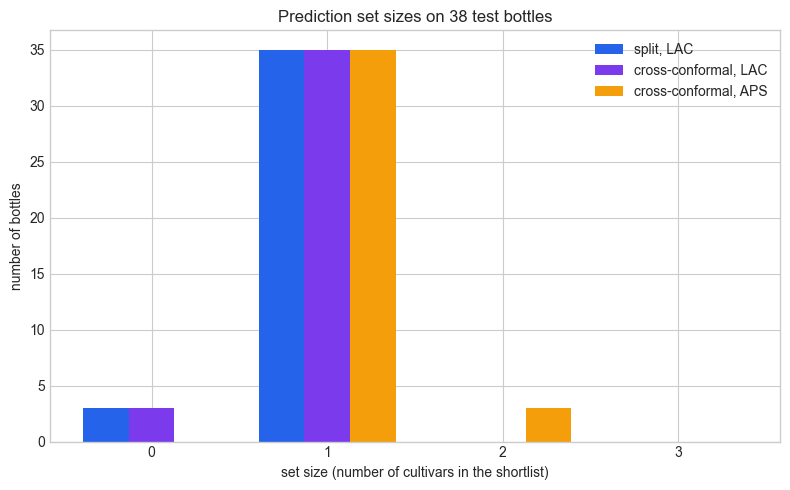

In [13]:
cross_aps = CrossConformalClassifier(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000,
                                                       random_state=RANDOM_SEED)),
    confidence_level=1 - alpha, conformity_score="aps", cv=10,
    random_state=RANDOM_SEED,
)
cross_aps.fit_conformalize(Xw_pool, yw_pool)
_, sets_aps = cross_aps.predict_set(Xw_test)
sizes_aps = sets_aps[:, :, 0].sum(axis=1)
coverage_aps = classification_coverage_score(yw_test, sets_aps)[0]
print(f"cross-conformal (cv=10, APS): coverage {coverage_aps:.4f}, "
      f"average set size {sizes_aps.mean():.3f}")
print(f"set sizes 0/1/2/3: {np.bincount(sizes_aps.astype(int), minlength=4)}")

# AMBER for the third method: GREEN stays reserved for covered/good in this series.
methods = [("split, LAC", sizes_w, BLUE),
           ("cross-conformal, LAC", sizes_cw, PURPLE),
           ("cross-conformal, APS", sizes_aps, AMBER)]
size_range = np.arange(4)
bar_w = 0.26

fig, ax = plt.subplots(figsize=(8, 5))
for i, (name, sizes, color) in enumerate(methods):
    counts = [(sizes == s).sum() for s in size_range]
    ax.bar(size_range + (i - 1) * bar_w, counts, width=bar_w, color=color, label=name)
ax.set_xticks(size_range)
ax.set_title("Prediction set sizes on 38 test bottles")
ax.set_xlabel("set size (number of cultivars in the shortlist)")
ax.set_ylabel("number of bottles")
ax.legend()
plt.tight_layout()
plt.show()

APS empties the size-zero bin — every bottle now gets at least one cultivar — and pays
for it in the size-two bin: three bottles get a two-cultivar shortlist instead of a blank
or a guess, and the average set size rises from 0.921 to 1.079. Coverage prints 1.0000,
and one caution before anyone celebrates: that is 38 of 38 on a tiny test set, not a new
guarantee. APS typically overcovers its target — the cumulative construction is
conservative by design — and on 38 bottles a conservative procedure covering everything
is unremarkable. The real lesson is the shape of the trade: LAC buys the smallest average
sets and tolerates empties, APS buys never-empty, difficulty-tracking sets and tolerates
a little bulk. Which one ships is a product decision — which is why it is an argument in
the API rather than a default you should trust blindly.

## 6. The translation table

Everything this series taught under one name exists in MAPIE under another. Pin this
table to the repo README so the next junior engineer does not need eight notebooks to
decode the API.

| This series says | MAPIE 1.4 says | Watch out |
|---|---|---|
| nonconformity score | `conformity_score=` (`"absolute"`, `"gamma"`, ... ; classifiers: `"lac"`, `"aps"`, `"raps"`) | Same weirdness meter; papers and libraries disagree on the name and sometimes the sign. |
| calibration set / calibrate | `.conformalize(X_cal, y_cal)`, "conformalization" | Never hand it training data — field guide §2 still applies inside a library. |
| alpha, the miscoverage budget | `confidence_level = 1 - alpha` | Passing alpha itself silently requests 10% coverage; we watched it happen in section 3. |
| split conformal (notebook 02) | `SplitConformalRegressor` / `SplitConformalClassifier` | `prefit=True` (the Split classes' default) means "already fitted, skip `.fit()` entirely"; pass `prefit=False` if MAPIE should train the estimator. |
| prediction interval / prediction set | `.predict_interval()` / `.predict_set()` | Returns shape `(n, 2, 1)` / `(n, n_classes, 1)`; the trailing axis indexes confidence levels — do not forget the final `[..., 0]`. |
| CQR (notebook 05) | `ConformalizedQuantileRegressor` | Defaults to `prefit=False` — the opposite of the Split classes — and fits three quantile models from your one estimator. |
| CV+ (notebook 06) | `CrossConformalRegressor(method="plus", cv=10)` | `fit_conformalize` wants ALL your data — pooling train and calibration is the point. An integer `cv` means a *shuffled* KFold: pass `random_state` or the folds change every run. |
| jackknife+ (notebook 06) | `JackknifeAfterBootstrapRegressor` | The bootstrap flavor of jackknife+: resampled models instead of n leave-one-out fits. |
| LAC / APS scores (notebook 04) | `conformity_score="lac"` / `"aps"` | LAC can return empty sets (section 5, live); APS trades a little size for never-empty. |
| Mondrian / class-conditional (notebook 04) | not in MAPIE 1.4's public API | Check the current docs before rolling your own; if absent, it is a groupby plus the fifteen lines. |

## 7. The pre-launch checklist

The operational summary of the whole series, as the yes/no list we would staple to any
launch review. Eight questions; "no" on any of them means you are not done.

1. **Was alpha chosen with the business owner, not defaulted?** A 90% target is a risk
   budget someone must own; 0.10 is this series' teaching default, not a law (notebook 01).
2. **Has the calibration data never touched training?** No fitting, no feature selection,
   no hyperparameter tuning on it. Split first, fit later, calibrate once (field guide §2).
3. **Was the implementation verified on a known case?** Corrected quantile with
   `method="higher"`, or the library reconciled against a hand-rolled reference the way
   section 3 did — down to the order statistic (field guide §1).
4. **Is the calibration set sized for the coverage lottery you can tolerate?** 40 points
   meant a 0.82–0.97 lottery in section 5; ~1,000 points holds a 90% target near
   0.88–0.92 (field guide §4).
5. **Has slice coverage been reviewed on the slices legal and product care about?**
   Marginal 0.907 hid a 0.879 slice in section 4. Per-class coverage in classification
   is the same review (field guide §3, §9).
6. **Is exchangeability argued in writing, and is there a shift plan?** One paragraph on
   why calibration and production data are shuffled from the same pool, plus monitoring
   for when they stop being so, plus the weighted-conformal playbook if the input mix
   moves (field guide §6, §10; notebook 07).
7. **Do large or empty sets route to a human instead of being suppressed?** Set size is
   the triage signal; capping it reinstates the false confidence you were hired to remove
   (field guide §7).
8. **Are coverage AND width monitored in production?** Coverage alone cannot detect a
   model going stale — width is where model quality shows up (field guide §5, §12).

## 8. Where to go next

A short shelf, mapped to the notebook that will make each one land:

- **Angelopoulos & Bates (2023), "A Gentle Introduction to Conformal Prediction and
  Distribution-Free Uncertainty Quantification"** — the tutorial this series leans on
  most, with runnable notebooks for every method; if you read one thing, read this.
- **Shafer & Vovk (2008), "A Tutorial on Conformal Prediction"** — the inventors'
  own walkthrough; if notebook 03's leaderboard argument hooked you, this is where that
  style of reasoning comes from.
- **Lei, G'Sell, Rinaldo, Tibshirani & Wasserman (2018), "Distribution-Free Predictive
  Inference for Regression"** — the regression workhorse paper behind notebooks 02 and 05,
  and the source of the do-not-average-splits warning (field guide §8).
- **Tibshirani, Barber, Candès & Ramdas (2019), "Conformal Prediction Under Covariate
  Shift"** — notebook 07 in its original form: weighted quantiles and the exact repair.
- **Vovk, Gammerman & Shafer (2005), "Algorithmic Learning in a Random World"** — the
  book: full conformal, online conformal, and the theory notebook 06 only sampled.
- **The MAPIE documentation** — current APIs, worked examples, and the migration guide
  from the pre-1.0 interface you will still find in older blog posts.
- **"Awesome Conformal Prediction"** — the community-maintained index of papers,
  libraries, and tutorials; the field moves fast and this list keeps up.

## 9. Common mistakes to avoid

1. **Mixing MAPIE 0.x and 1.x code.** Older tutorials use `MapieRegressor(estimator,
   ...)` with an `alpha=` argument; 1.x renamed the classes and the semantics. Copying a
   pre-1.0 snippet into a 1.4 environment fails loudly if you are lucky. Pin the version
   (we ran 1.4.1) and read the migration guide.
2. **Passing alpha where `confidence_level` is expected.** No error is raised — you simply
   get 10% coverage instead of 90%, as we demonstrated live: coverage 0.1045, intervals
   $9,658 wide. Keep a known-case coverage assertion in CI.
3. **Forgetting prefit semantics.** The Split classes default to `prefit=True`: MAPIE
   assumes your estimator is already fitted and will refuse to `.fit()` at all (a
   `ValueError` we hit while writing section 5 — pass `prefit=False` when you want MAPIE
   to do the fitting). `ConformalizedQuantileRegressor` defaults the other way, to
   `prefit=False`, which is why the section 4 cell passes it explicitly instead of
   leaning on a default that flips between classes. The reverse mistake is quieter: with
   `prefit=False`, `.fit()` re-trains the estimator you passed, slow at best and silently
   different at worst if your original was tuned.
4. **Trusting the default `conformity_score` without knowing which score it is.**
   `"absolute"` buys constant width; if the desk needs intervals that widen on hard
   inputs, you must ask for CQR or a scaled score (notebook 05). A default is a decision
   someone else made without seeing your slice table.
5. **Dropping the trailing axis.** `intervals` has shape `(n, 2, 1)` because MAPIE serves
   several confidence levels at once; `intervals[:, 0]` is still 2-D. Forgetting the final
   index produces broadcasting bugs that numpy will happily not report.
6. **Treating the library as the review.** MAPIE computes intervals; it does not choose
   alpha, verify exchangeability, read slice tables, or decide what happens to a
   nine-label set in production. Sections 1 and 7 are your job description; the library
   is the easy 20%.

## 10. What to say in the business review

**Strong version:**

> We standardized our uncertainty intervals on MAPIE, a maintained open-source library.
> Before adopting it we reconciled its output against our own audited implementation on an
> identical split of real pricing data: coverage matched exactly at 90.7% against a 90%
> target, and the interval half-widths agreed to within one dollar. We reviewed coverage
> by income segment, chose the quantile-based variant because the constant-width one
> under-covered the most expensive quartile at 87.9%, and hard cases route to the desk.
> Coverage and interval width are monitored in production, with an alert if either drifts.

**Weak version:**

> We installed a conformal prediction library and it says the intervals are 90% reliable.

The strong version names the library, proves it was verified rather than trusted, quotes
the slice that drove the design choice, and commits to monitoring. The weak version
outsources a promise to a pip install — and the desk has already lived through what an
unexamined promise costs (notebook 01).

### The one-line summary

Eight notebooks ago a confident point prediction lost the company money; today a
maintained library ships intervals whose every number we can reproduce, audit, and
monitor — and the parts no library provides (choosing alpha, guarding exchangeability,
reading the slice table, routing the hard cases) are now yours to own. Wherever you
deploy next, may your calibration data stay untouched and your slices stay green.

Uncertainty was always in the data; conformal prediction just makes the model admit it.